| **BO3: Aligner les programmes éducatifs sur les besoins futurs du marché du travail** | Identifier les pays où certains métiers augmentent ou diminuent fortement clustering avec K_Means O DBSCAN | Clustering |   K-Means on TF-IDF, HDBSCAN |

# **clusetering**

In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
 
# Load engineered data for clustering
df_engineered = pd.read_csv(r"C:\Users\meria\Downloads\mlProject\engineered_data.csv")
print(f"✅ Engineered data loaded: {df_engineered.shape}")

# Load PCA data for clustering  
dataset_reduit = pd.read_csv(r"C:\Users\meria\Downloads\mlProject\dataset_reduit.csv")
print(f"✅ PCA data loaded: {dataset_reduit.shape}")

✅ Engineered data loaded: (30000, 15)
✅ PCA data loaded: (30000, 21)


In [3]:
print("\n🔍 DATA PREVIEW - Engineered Data:")
print(df_engineered.head(3))
print("\n🔍 DATA PREVIEW - PCA Data:")
print(dataset_reduit.head(3))
print(f"\n📊 df_engineered shape: {df_engineered.shape}")
X_pca = dataset_reduit.values



🔍 DATA PREVIEW - Engineered Data:
               Job_Title       Industry  Job_Status AI_Impact_Level  \
0     investment analyst             it  increasing        moderate   
1  journalist, newspaper  manufacturing  increasing        moderate   
2      financial planner        finance  increasing             low   

   Median_Salary_USD Required_Education  Experience_Required_Years  \
0           42109.76    master's degree                        5.0   
1          132298.57    master's degree                       15.0   
2          143279.19  bachelor's degree                        4.0   

   Remote_Work_Ratio_%  Automation_Risk_% Location  Gender_Diversity_%  \
0                55.96              28.28       uk               44.63   
1                16.81              89.71      usa               66.39   
2                91.82              72.97   canada               41.13   

   Job_Growth_Rate_% Growth_Category  Job_Value_Index  Vulnerability_Index  
0         318.613861     

# **KMeans**

In [4]:
# Select features relevant for BO3 clustering
country_features = [
    'Job_Growth_Rate_%',   
    'Median_Salary_USD',        
    'Automation_Risk_%',          
    'Remote_Work_Ratio_%',      
]
print(f"🔍 Using BO3-relevant features: {country_features}")
X_country = df_engineered[country_features].copy()

scaler = StandardScaler()
X_country_scaled = scaler.fit_transform(X_country)
print(f"Clustering data shape: {X_country_scaled.shape}")

🔍 Using BO3-relevant features: ['Job_Growth_Rate_%', 'Median_Salary_USD', 'Automation_Risk_%', 'Remote_Work_Ratio_%']
Clustering data shape: (30000, 4)


In [5]:
K_range = range(2, 8)
inertia = []
sil_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_country_scaled)
    inertia.append(kmeans.inertia_)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_country_scaled)
    score = silhouette_score(X_country_scaled, labels)
    sil_scores.append(score)

optimal_k = K_range[np.argmax(sil_scores)]
print(f"Optimal k determined by silhouette score: {optimal_k}")

Optimal k determined by silhouette score: 7


In [6]:
# Show all scores
print("\nSilhouette Scores:")
for k, score in zip(K_range, sil_scores):
    print(f"k={k}: {score:.3f}")
# Apply K-means with optimal k
kmeans_optimized = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_engineered['KMeans_Cluster'] = kmeans_optimized.fit_predict(X_country_scaled)

print(f"\nClustering applied with k={optimal_k}")
print("Cluster distribution:")
print(df_engineered['KMeans_Cluster'].value_counts().sort_index())


Silhouette Scores:
k=2: 0.217
k=3: 0.211
k=4: 0.231
k=5: 0.247
k=6: 0.245
k=7: 0.260

Clustering applied with k=7
Cluster distribution:
KMeans_Cluster
0    4875
1    4814
2    4900
3    4847
4     593
5    4820
6    5151
Name: count, dtype: int64


**Visualisation de la courbe de coude**

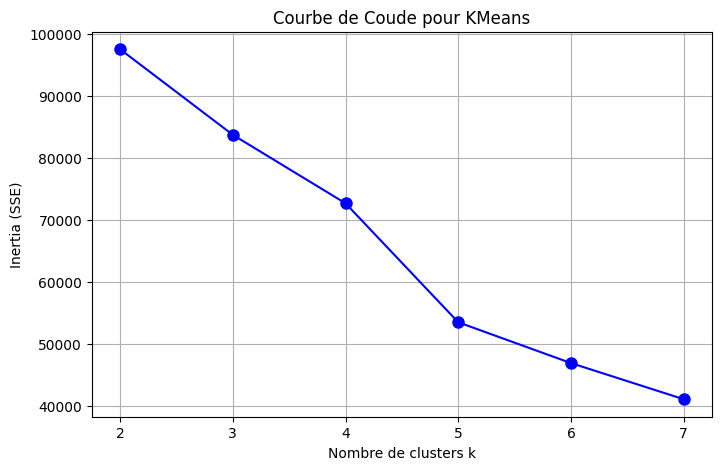

In [7]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertia (SSE)")
plt.title("Courbe de Coude pour KMeans")
plt.grid(True)
plt.show()

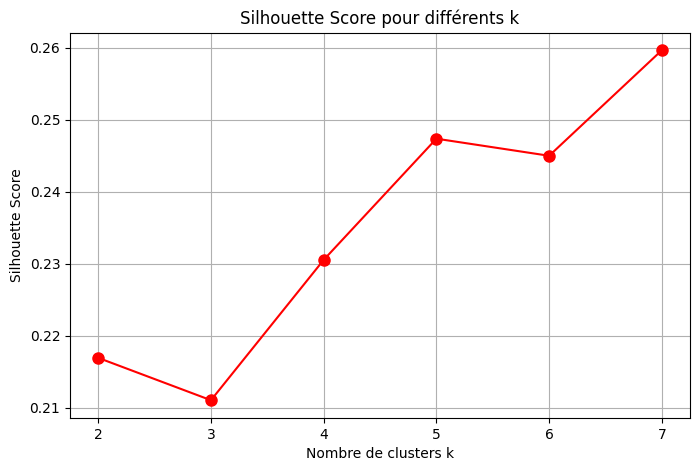

In [8]:
plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, 'ro-', markersize=8)
plt.xlabel("Nombre de clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score pour différents k")
plt.grid(True)
plt.show()

**VISUALISATION DES CLUSTERS**

Distribution des clusters KMeans:
KMeans_Cluster
0    4875
1    4814
2    4900
3    4847
4     593
5    4820
6    5151
Name: count, dtype: int64


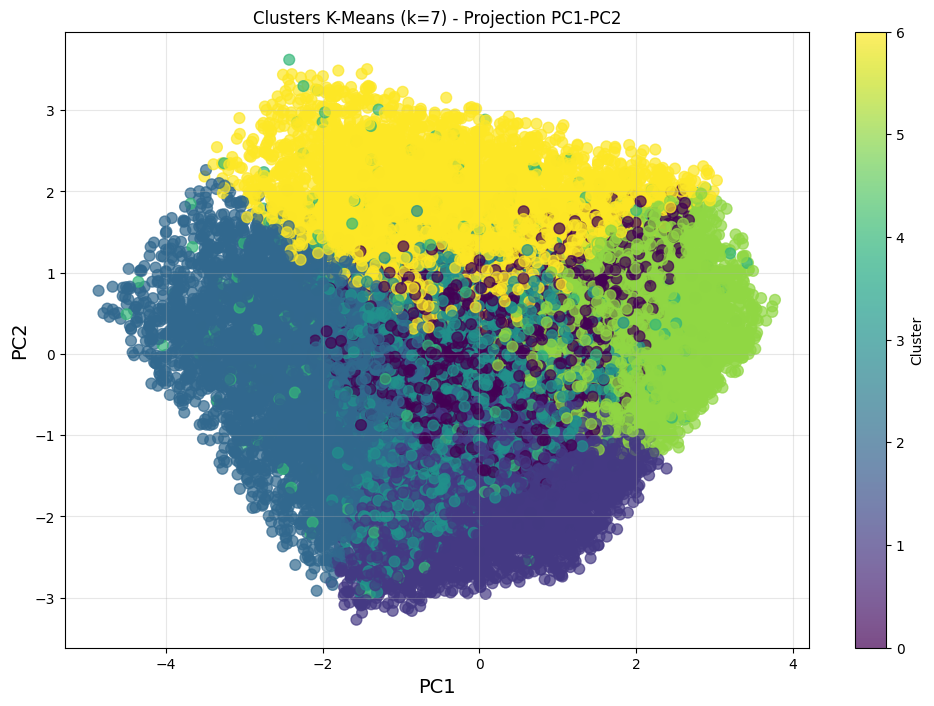

In [9]:
# **VISUALISATION  DES CLUSTERS KMEANS**

# Distribution des clusters
cluster_distribution = df_engineered['KMeans_Cluster'].value_counts().sort_index()
print("Distribution des clusters KMeans:")
print(cluster_distribution)

# Visualisation PC1 vs PC2 avec les vraies étiquettes
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=df_engineered['KMeans_Cluster'].values, 
                     cmap='viridis', alpha=0.7, s=60)
plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
plt.title(f'Clusters K-Means (k={optimal_k}) - Projection PC1-PC2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
for country in df_engineered['Location'].unique():
    print(f"=== {country} ===")
    for cluster in df_engineered['KMeans_Cluster'].unique():
        subset = df_engineered[(df_engineered['Location'] == country) & (df_engineered['KMeans_Cluster'] == cluster)]
        if len(subset) == 0:
            continue
        # Top 5 métiers du cluster
        top_jobs = [str(job) for job in subset['Job_Title'].value_counts().head(5).index.tolist()]
        # Moyennes des indicateurs
        mean_growth = subset['Job_Growth_Rate_%'].mean().round(2)
        mean_salary = subset['Median_Salary_USD'].mean().round(2)
        mean_risk = subset['Automation_Risk_%'].mean().round(2)
        
        # Affichage
        print(f"Cluster {cluster}:")
        print(f"  Croissance moyenne : {mean_growth}%")
        print(f"  Salaire moyen : {mean_salary} USD")
        print(f"  Risque d'automatisation : {mean_risk}%")
        print(f"  Métiers principaux : {', '.join(top_jobs)}")
        print(f"  Interprétation : ...\n")


=== uk ===
Cluster 1:
  Croissance moyenne : 58.55%
  Salaire moyen : 57608.33 USD
  Risque d'automatisation : 37.65%
  Métiers principaux : forest/woodland manager, secondary school teacher, forensic psychologist, associate professor, international aid/development worker
  Interprétation : ...

Cluster 6:
  Croissance moyenne : 69.52%
  Salaire moyen : 124170.36 USD
  Risque d'automatisation : 60.67%
  Métiers principaux : designer, television/film set, media planner, audiological scientist, clinical embryologist, fashion designer
  Interprétation : ...

Cluster 3:
  Croissance moyenne : 68.83%
  Salaire moyen : 108241.91 USD
  Risque d'automatisation : 77.76%
  Métiers principaux : proofreader, herpetologist, media planner, designer, television/film set, amenity horticulturist
  Interprétation : ...

Cluster 5:
  Croissance moyenne : 63.12%
  Salaire moyen : 119463.99 USD
  Risque d'automatisation : 22.91%
  Métiers principaux : radiographer, diagnostic, higher education lecturer, in

In [11]:
# Cluster characteristics
print(f"\n CARACTÉRISTIQUES DES {optimal_k} CLUSTERS:")
cluster_profiles = []
for cluster in sorted(df_engineered['KMeans_Cluster'].unique()):
    cluster_data = df_engineered[df_engineered['KMeans_Cluster'] == cluster]
    
    growth = cluster_data['Job_Growth_Rate_%'].mean().round(2)
    salary = cluster_data['Median_Salary_USD'].mean().round(2)
    risk = cluster_data['Automation_Risk_%'].mean().round(2)
    count = len(cluster_data)
    top_jobs = cluster_data['Job_Title'].value_counts().head(3).index.tolist()
    
    # Label clusters based on growth
    if growth > 10:
        cluster_type = " FORTE CROISSANCE"
    elif growth < -5:
        cluster_type = " FORT DÉCLIN" 
    elif growth > 0:
        cluster_type = "↗ CROISSANCE MODÉRÉE"
    else:
        cluster_type = " STABLE"
    
    cluster_profiles.append({
        'cluster': cluster, 'growth': growth, 'salary': salary, 
        'risk': risk, 'count': count, 'top_jobs': top_jobs, 'type': cluster_type
    })
    
    print(f"\n{cluster_type} - Cluster {cluster}:")
    print(f"   Croissance: {growth}%")
    print(f"   Salaire moyen: {salary} USD")
    print(f"   Risque automation: {risk}%")
    print(f"   {count} métiers")
    print(f"    Métiers: {', '.join(top_jobs)}")



 CARACTÉRISTIQUES DES 7 CLUSTERS:

 FORTE CROISSANCE - Cluster 0:
   Croissance: 76.59%
   Salaire moyen: 71183.39 USD
   Risque automation: 22.76%
   4875 métiers
    Métiers: occupational therapist, investment banker, operational, dentist

 FORTE CROISSANCE - Cluster 1:
   Croissance: 69.31%
   Salaire moyen: 56802.48 USD
   Risque automation: 37.84%
   4814 métiers
    Métiers: midwife, designer, furniture, surveyor, land/geomatics

 FORTE CROISSANCE - Cluster 2:
   Croissance: 85.54%
   Salaire moyen: 58731.0 USD
   Risque automation: 77.36%
   4900 métiers
    Métiers: speech and language therapist, therapist, speech and language, insurance claims handler

 FORTE CROISSANCE - Cluster 3:
   Croissance: 78.48%
   Salaire moyen: 108950.21 USD
   Risque automation: 77.91%
   4847 métiers
    Métiers: dancer, proofreader, teacher, special educational needs

 FORTE CROISSANCE - Cluster 4:
   Croissance: 3343.56%
   Salaire moyen: 89789.73 USD
   Risque automation: 50.33%
   593 métiers

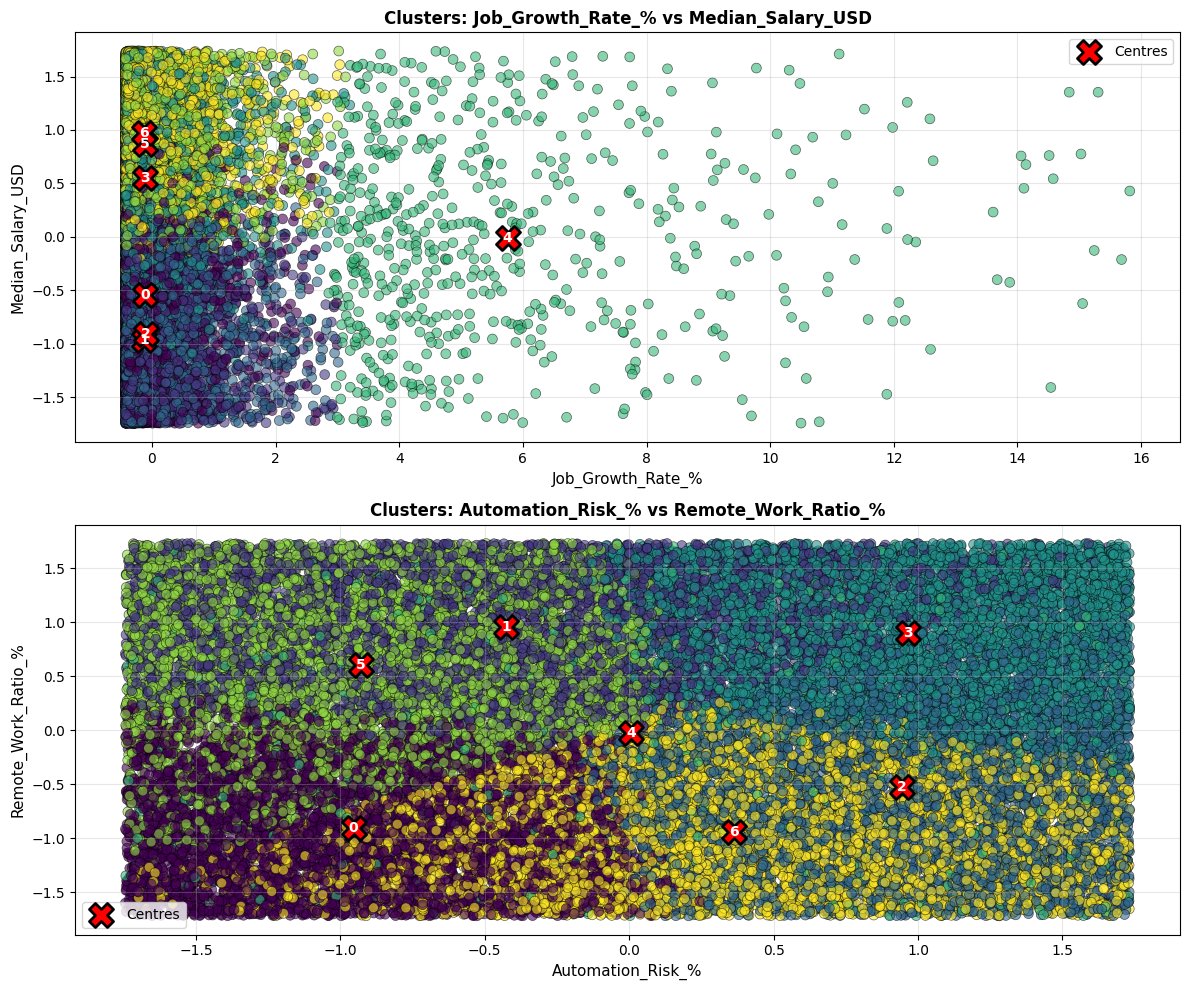

In [12]:
def plot_cluster_multidim(X_scaled, labels, centers, feature_names, optimal_k):
  
    n_features = X_scaled.shape[1]
    n_pairs = min(3, n_features // 2)  # Maximum 3 paires
    
    fig, axes = plt.subplots(n_pairs, 1, figsize=(12, 5 * n_pairs))
    
    # Gérer le cas d'un seul subplot
    if n_pairs == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        idx_x = 2 * i
        idx_y = 2 * i + 1
        
        if idx_y < n_features:
            # Points des clusters
            scatter = ax.scatter(X_scaled[:, idx_x], X_scaled[:, idx_y],
                               c=labels, cmap='viridis', alpha=0.6, s=50,
                               edgecolors='k', linewidth=0.5)
            
            # Centres des clusters
            ax.scatter(centers[:, idx_x], centers[:, idx_y], 
                      c='red', s=300, marker='X', edgecolors='black', 
                      linewidth=2, label='Centres', zorder=10)
            
            # Numérotation des centres
            for cluster_id, center in enumerate(centers):
                ax.text(center[idx_x], center[idx_y], str(cluster_id),
                       fontsize=10, fontweight='bold', color='white',
                       ha='center', va='center', zorder=11)
            
            ax.set_xlabel(feature_names[idx_x], fontsize=11)
            ax.set_ylabel(feature_names[idx_y], fontsize=11)
            ax.set_title(f'Clusters: {feature_names[idx_x]} vs {feature_names[idx_y]}',
                        fontsize=12, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_cluster_multidim(X_country_scaled, 
                     df_engineered['KMeans_Cluster'].values,
                     kmeans_optimized.cluster_centers_,
                     country_features,
                     optimal_k)


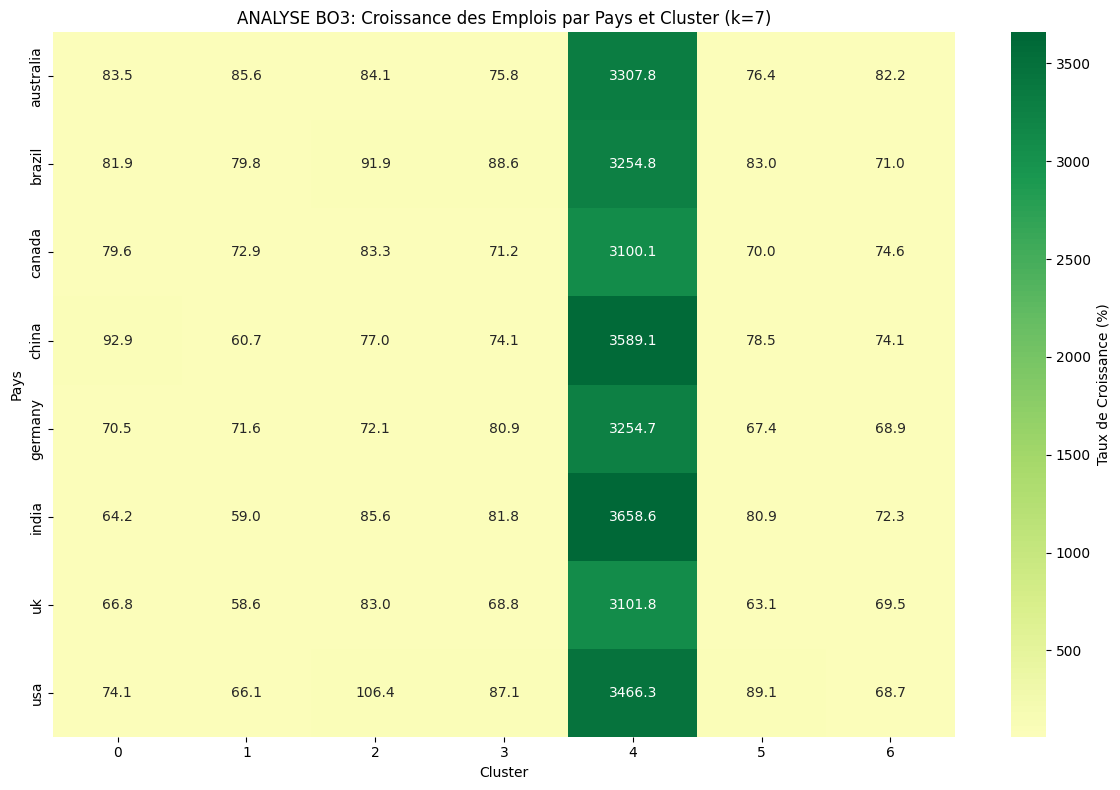

In [13]:
# Heatmap showing growth by country and cluster
plt.figure(figsize=(12, 8))
growth_pivot = df_engineered.pivot_table(
    values='Job_Growth_Rate_%', 
    index='Location', 
    columns='KMeans_Cluster', 
    aggfunc='mean'
)
sns.heatmap(growth_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            cbar_kws={'label': 'Taux de Croissance (%)'})
plt.title(f'ANALYSE BO3: Croissance des Emplois par Pays et Cluster (k={optimal_k})')
plt.xlabel('Cluster')
plt.ylabel('Pays')
plt.tight_layout()
plt.show()

# **K_MEANS   dataset reduit** 

In [14]:
# **PRE-PROCESSING**
# Sélection des composantes PCA pour le clustering
pca_columns = [col for col in dataset_reduit.columns if col.startswith('PC')]
X = dataset_reduit[pca_columns].copy()
print(f"Variables utilisées pour le clustering: {pca_columns}")
print(f"Shape des données pour clustering: {X.shape}")
# Normalisation des données (comme dans l'exemple World Happiness)
X_values = X.values
X_values = np.nan_to_num(X_values)  # Remplace les NaN par 0
Clus_dataSet = StandardScaler().fit_transform(X_values)

print("✅ Données normalisées et prêtes pour le clustering")

Variables utilisées pour le clustering: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18']
Shape des données pour clustering: (30000, 18)
✅ Données normalisées et prêtes pour le clustering


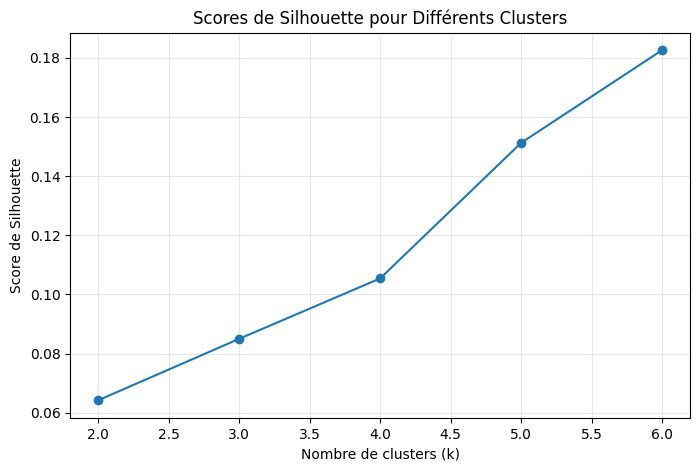

✅ Meilleur k selon silhouette: 6
📊 Meilleur score de silhouette: 0.183


In [15]:
silhouette_scores = []

K_range = range(2, 7)  # same range for fit and plot
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(Clus_dataSet)
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(Clus_dataSet, labels))

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Scores de Silhouette pour Différents Clusters')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score de Silhouette')
plt.grid(True, alpha=0.3)
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f"✅ Meilleur k selon silhouette: {best_k}")
print(f"📊 Meilleur score de silhouette: {max(silhouette_scores):.3f}")


In [16]:
# **APPLICATION DE K-MEANS AVEC LE MEILLEUR K**
print(f"\n🎯 APPLICATION DE K-MEANS AVEC k={best_k}...")

clusterNum = best_k
k_means = KMeans(init="k-means++", n_clusters=clusterNum, n_init=12)
k_means.fit(Clus_dataSet)

# Groupes construits
labels = k_means.labels_
print("Labels des clusters (10 premiers):", labels[:10])

# Get the cluster centers
centers = k_means.cluster_centers_
print(f"\nCentres des clusters (shape: {centers.shape})")

# Get the inertia
inertia = k_means.inertia_
print(f"Inertie: {inertia:.2f}")

# Score de silhouette final
silhouette_avg = silhouette_score(Clus_dataSet, labels)
print(f"Score de Silhouette final: {silhouette_avg:.3f}")


🎯 APPLICATION DE K-MEANS AVEC k=6...
Labels des clusters (10 premiers): [3 2 4 3 3 0 2 3 0 2]

Centres des clusters (shape: (6, 18))
Inertie: 390827.69


Score de Silhouette final: 0.182



📊 PHASE D'INSIGHTS

Aperçu des données avec clusters:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -0.013697 -1.297713 -1.309655 -1.020011 -0.678511 -1.115369 -1.902685   
1 -1.726004  2.444325  1.379046  0.950426  0.470645  0.336191  1.093795   
2  1.230255  0.140822 -1.822413  0.399887 -1.386898  0.966564  0.292732   
3 -3.508264  2.183678  0.062516  1.946277  1.211507  0.462832 -1.123079   
4  0.033371 -0.826733 -1.517286 -1.253607  0.457990  0.988800 -0.863129   

        PC8       PC9      PC10  ...      PC13      PC14      PC15      PC16  \
0  1.476980  0.035599  1.823552  ... -0.807587  0.034256 -0.614458  0.535987   
1 -1.638459 -0.945801  2.236097  ... -0.593537 -0.997776  0.453375  0.467345   
2 -0.460538 -0.047968 -0.981484  ... -0.497098  0.054309  1.046729  1.825471   
3  0.743107 -1.132999 -0.565709  ... -0.856043  0.427976 -0.826677 -1.196400   
4  1.251471 -1.178987  0.122252  ...  0.433215 -1.751540 -0.393107 -0.625786   

       PC17  

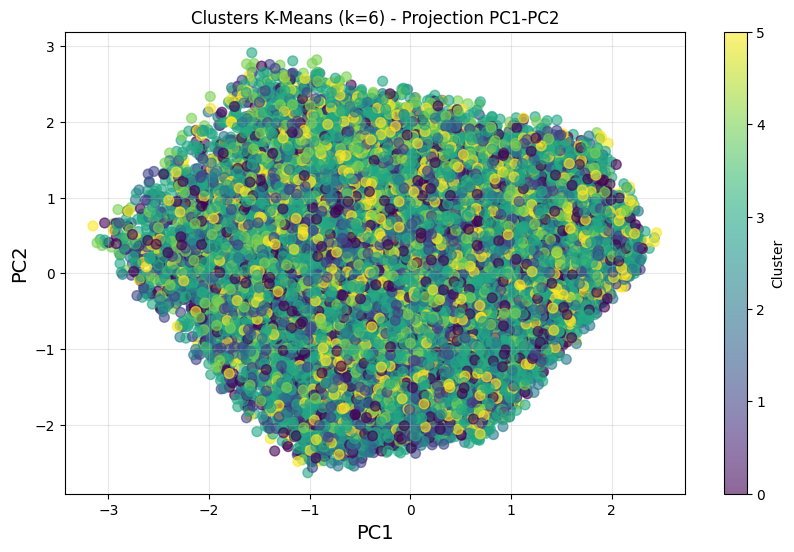

In [17]:
# **INSIGHTS - AJOUT DES LABELS AU DATASET**
print("\n" + "="*50)
print("📊 PHASE D'INSIGHTS")
print("="*50)

dataset_reduit["Cluster"] = labels
print("\nAperçu des données avec clusters:")
print(dataset_reduit.head())

print("\nDistribution des clusters:")
cluster_distribution = dataset_reduit["Cluster"].value_counts().sort_index()
print(cluster_distribution)
# **VISUALISATION DES CLUSTERS**
print("🎨 PHASE DE VISUALISATION")
# 1. Visualisation basique PC1 vs PC2 avec les clusters
plt.figure(figsize=(10, 6))
plt.scatter(Clus_dataSet[:, 0], Clus_dataSet[:, 1], c=labels.astype(float), alpha=0.6, s=50)
plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
plt.title(f'Clusters K-Means (k={best_k}) - Projection PC1-PC2')
plt.colorbar(label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

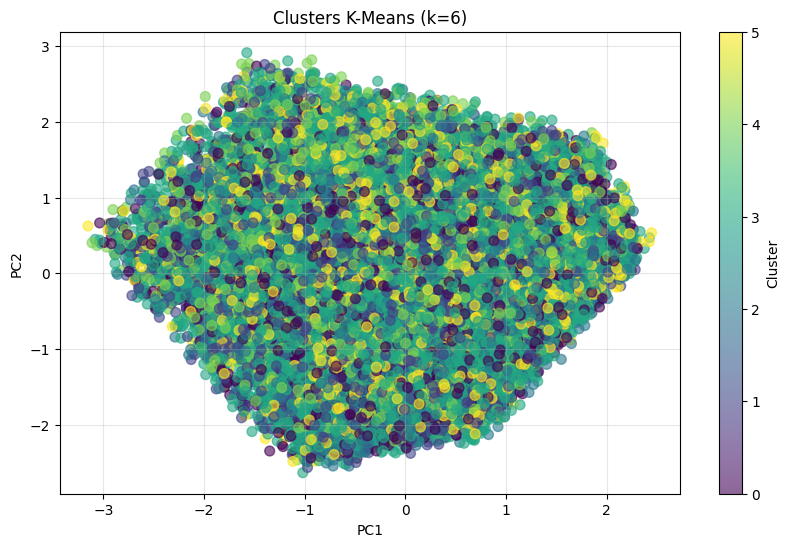

In [18]:
# 2. Visualisation avec taille des points basée sur une variable si disponible
plt.figure(figsize=(10, 6))

# Si nous avons une variable de croissance, l'utiliser pour la taille des points
if 'Job_Growth_Rate_%' in dataset_reduit.columns:
    sizes = np.abs(dataset_reduit['Job_Growth_Rate_%']) * 10  # Échelle pour la visibilité
    scatter = plt.scatter(Clus_dataSet[:, 0], Clus_dataSet[:, 1], c=labels.astype(float), 
                         s=sizes, alpha=0.6, cmap='viridis')
    plt.colorbar(scatter, label='Cluster')
    plt.title(f'Clusters K-Means - Taille basée sur le taux de croissance')
else:
    scatter = plt.scatter(Clus_dataSet[:, 0], Clus_dataSet[:, 1], c=labels.astype(float), 
                         alpha=0.6, s=50, cmap='viridis')
    plt.colorbar(scatter, label='Cluster')
    plt.title(f'Clusters K-Means (k={best_k})')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# **ANALYSE DES CARACTÉRISTIQUES PAR CLUSTER**
print("\n📈 ANALYSE DES CARACTÉRISTIQUES PAR CLUSTER...")

# Vérification des colonnes disponibles pour l'analyse
available_columns = dataset_reduit.columns.tolist()
print(f"Colonnes disponibles: {[col for col in available_columns if not col.startswith('PC')]}")

# Statistiques par cluster
cluster_analysis_cols = ['Cluster']
if 'Job_Growth_Rate_%' in dataset_reduit.columns:
    cluster_analysis_cols.append('Job_Growth_Rate_%')
if 'AI_Impact_Level' in dataset_reduit.columns:
    cluster_analysis_cols.append('AI_Impact_Level')
if 'Growth_Category' in dataset_reduit.columns:
    cluster_analysis_cols.append('Growth_Category')

if len(cluster_analysis_cols) > 1:
    cluster_stats = dataset_reduit[cluster_analysis_cols].groupby('Cluster').agg({
        col: ['mean', 'std'] if dataset_reduit[col].dtype in ['float64', 'int64'] 
        else lambda x: x.mode()[0] if len(x.mode()) > 0 else 'unknown'
        for col in cluster_analysis_cols if col != 'Cluster'
    }).round(2)
    
    print("📊 STATISTIQUES PAR CLUSTER:")
    print(cluster_stats)
else:
    # Si seulement les composantes PCA sont disponibles
    pca_stats = dataset_reduit.groupby('Cluster')[pca_columns].mean().round(2)
    print("📊 STATISTIQUES PCA PAR CLUSTER:")
    print(pca_stats)


📈 ANALYSE DES CARACTÉRISTIQUES PAR CLUSTER...
Colonnes disponibles: ['Job_Title', 'Growth_Category', 'AI_Impact_Level', 'Cluster']
📊 STATISTIQUES PAR CLUSTER:
        AI_Impact_Level Growth_Category
Cluster                                
0                   low         decline
1                   low         decline
2              moderate     high_growth
3              moderate     high_growth
4                  high     high_growth
5                   low     high_growth



📊 HEATMAP DES CARACTÉRISTIQUES MOYENNES PAR CLUSTER...


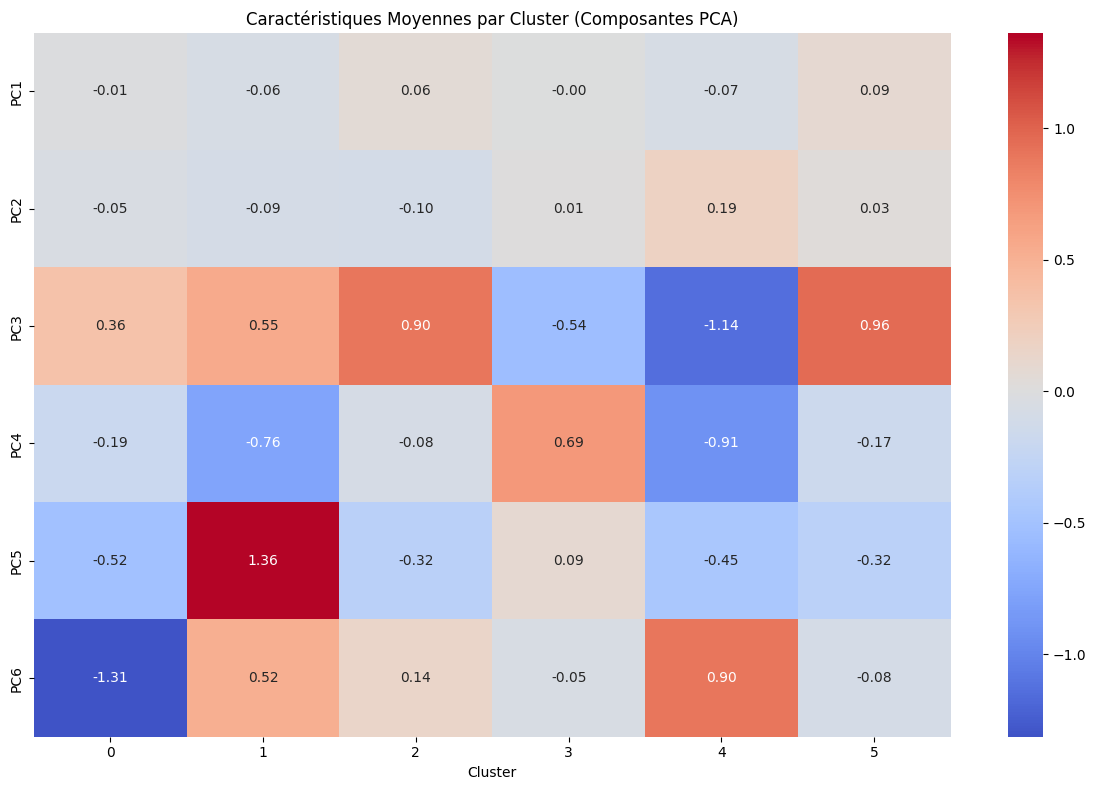

In [20]:
# **HEATMAP DES CARACTÉRISTIQUES**
print("\n📊 HEATMAP DES CARACTÉRISTIQUES MOYENNES PAR CLUSTER...")

# Préparation des données pour la heatmap
heatmap_data = dataset_reduit.groupby('Cluster')[pca_columns[:6]].mean()  # Premières 6 composantes

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data.T, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Caractéristiques Moyennes par Cluster (Composantes PCA)')
plt.tight_layout()
plt.show()

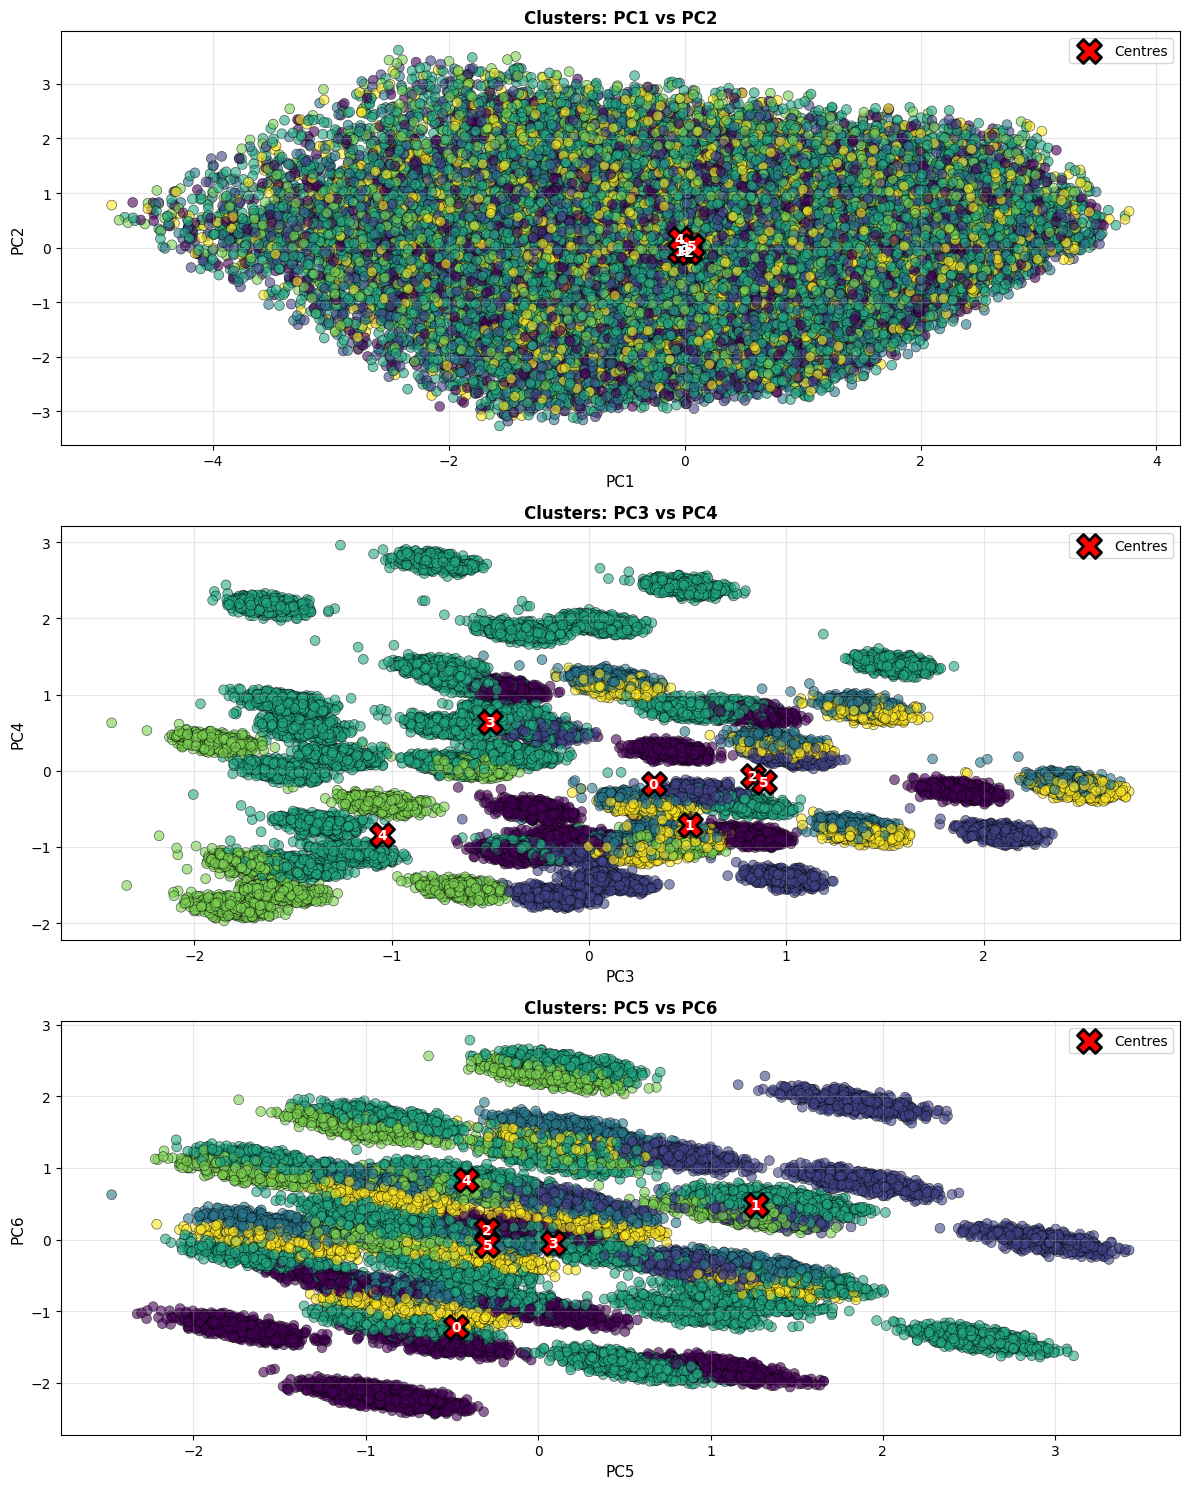

In [21]:
def plot_cluster_multidim(X_scaled, labels, centers, feature_names, optimal_k):
  
    n_features = X_scaled.shape[1]
    n_pairs = min(3, n_features // 2)  # Maximum 3 paires
    
    fig, axes = plt.subplots(n_pairs, 1, figsize=(12, 5 * n_pairs))
    
    # Gérer le cas d'un seul subplot
    if n_pairs == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        idx_x = 2 * i
        idx_y = 2 * i + 1
        
        if idx_y < n_features:
            # Points des clusters
            scatter = ax.scatter(X_scaled[:, idx_x], X_scaled[:, idx_y],
                               c=labels, cmap='viridis', alpha=0.6, s=50,
                               edgecolors='k', linewidth=0.5)
            
            # Centres des clusters
            ax.scatter(centers[:, idx_x], centers[:, idx_y], 
                      c='red', s=300, marker='X', edgecolors='black', 
                      linewidth=2, label='Centres', zorder=10)
            
            # Numérotation des centres
            for cluster_id, center in enumerate(centers):
                ax.text(center[idx_x], center[idx_y], str(cluster_id),
                       fontsize=10, fontweight='bold', color='white',
                       ha='center', va='center', zorder=11)
            
            ax.set_xlabel(feature_names[idx_x], fontsize=11)
            ax.set_ylabel(feature_names[idx_y], fontsize=11)
            ax.set_title(f'Clusters: {feature_names[idx_x]} vs {feature_names[idx_y]}',
                        fontsize=12, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_cluster_multidim(X_pca, 
                     dataset_reduit['Cluster'].values,
                     k_means.cluster_centers_,
                     pca_columns,
                     best_k)


# **DBSCAN**

🔍 Utilisation des mêmes données que K-means
Features: ['Job_Growth_Rate_%', 'Median_Salary_USD', 'Automation_Risk_%', 'Remote_Work_Ratio_%']
Shape: (30000, 4)

📏 CALCUL DE minPts:
 • Nombre de features = 4
 • minPts = D + 1 = 5


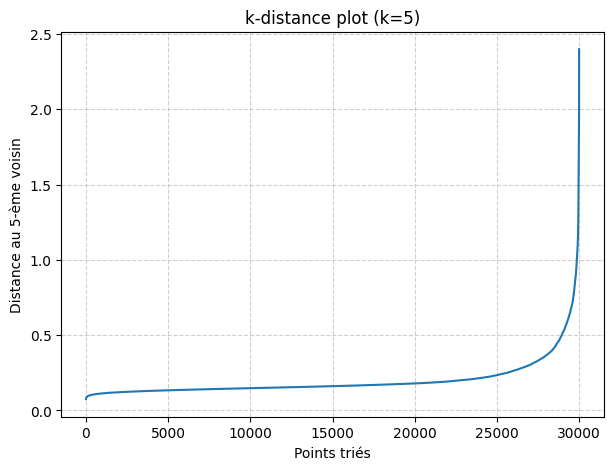

In [22]:
print("🔍 Utilisation des mêmes données que K-means")
print(f"Features: {country_features}")
print(f"Shape: {X_country_scaled.shape}")

D = len(country_features)
minPts = D + 1   # règle standard DBSCAN
print("\n📏 CALCUL DE minPts:")
print(f" • Nombre de features = {D}")
print(f" • minPts = D + 1 = {minPts}")

# ---- k-distance pour un premier aperçu
nbrs = NearestNeighbors(n_neighbors=minPts).fit(X_country_scaled)
k_dists, _ = nbrs.kneighbors(X_country_scaled)
k_dists = np.sort(k_dists[:, -1])

plt.figure(figsize=(7,5))
plt.plot(k_dists)
plt.title(f"k-distance plot (k={minPts})")
plt.xlabel("Points triés")
plt.ylabel(f"Distance au {minPts}-ème voisin")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [23]:
# Candidats epsilon

epsilon_p90 = np.percentile(k_dists, 90)
epsilon_p95 = np.percentile(k_dists, 95)
epsilon_mean = np.mean(k_dists)

print("\nCANDIDATS EPSILON (basés sur la distribution):")
print(f" • Percentile 90% : {epsilon_p90:.3f}")
print(f" • Percentile 95% : {epsilon_p95:.3f}")
print(f" • Moyenne : {epsilon_mean:.3f}")

# ---- Grille d'epsilon élargie autour des valeurs
eps_candidates = np.concatenate([
    np.linspace(epsilon_p90*0.6, epsilon_p90*1.4, 6),
    np.linspace(epsilon_p95*0.6, epsilon_p95*1.4, 6),
    np.linspace(epsilon_mean*0.6, epsilon_mean*1.4, 6)
])

eps_candidates = np.round(eps_candidates, 3)
eps_candidates = np.unique(eps_candidates)
eps_candidates = eps_candidates[eps_candidates > 0]
eps_candidates = sorted(eps_candidates.tolist())

print("\nListe étendue des eps testés:")
print(eps_candidates)



CANDIDATS EPSILON (basés sur la distribution):
 • Percentile 90% : 0.302
 • Percentile 95% : 0.419
 • Moyenne : 0.199

Liste étendue des eps testés:
[0.12, 0.152, 0.181, 0.183, 0.215, 0.229, 0.247, 0.251, 0.278, 0.279, 0.319, 0.326, 0.374, 0.386, 0.422, 0.453, 0.52, 0.587]


In [24]:
# SECTION 3 — Test de tous les eps
results = []
for eps in eps_candidates:
    db = DBSCAN(eps=eps, min_samples=minPts).fit(X_country_scaled)
    labels = db.labels_
    
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Score simple : favoriser moins de bruit et entre 2 et 15 clusters
    if 2 <= n_clusters <= 15:
        quality = (1 - noise_ratio) * n_clusters
    else:
        quality = -1  # non raisonnable
    
    results.append([eps, n_clusters, noise_ratio, quality])

df_grid = pd.DataFrame(results, columns=["eps", "n_clusters", "noise_ratio", "quality"])

print("\nAperçu de la grille:")
display(df_grid.head())

# ---- filtrer les eps raisonnables
reasonable = df_grid[(df_grid.n_clusters.between(2, 15))]
reasonable = reasonable.sort_values(by="quality", ascending=False)

print("\nEPS raisonnables triés:")
display(reasonable.head())

# ---- choix final
if len(reasonable) > 0:
    best_epsilon = reasonable.iloc[0]["eps"]
else:
    best_epsilon = epsilon_p90  # fallback
print(f"\n🎯 EPSILON FINAL CHOISI = {best_epsilon}")



Aperçu de la grille:


,eps,n_clusters,noise_ratio,quality
0,0.120,747,0.823267,-1.0
1,0.152,305,0.368800,-1.0
2,0.181,40,0.213133,-1.0
3,0.183,44,0.208200,-1.0
4,0.215,30,0.151867,-1.0



EPS raisonnables triés:


,eps,n_clusters,noise_ratio,quality
15,0.453,15,0.032433,14.5135



🎯 EPSILON FINAL CHOISI = 0.453



📊 RÉSULTATS DBSCAN:
 • Clusters détectés : 15
 • Bruit : 973 (3.2%)
 • Labels : [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


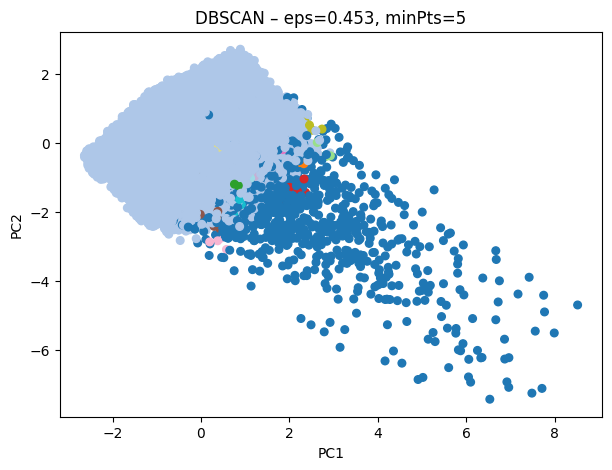

In [25]:
#  DBSCAN 
dbscan = DBSCAN(eps=best_epsilon, min_samples=minPts)
dbscan_labels = dbscan.fit_predict(X_country_scaled)

df_engineered["DBSCAN_Cluster"] = dbscan_labels

unique_labels = np.unique(dbscan_labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("\n📊 RÉSULTATS DBSCAN:")
print(f" • Clusters détectés : {n_clusters}")
print(f" • Bruit : {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(f" • Labels : {unique_labels}")


pca_vis = PCA(n_components=2).fit_transform(X_country_scaled)

plt.figure(figsize=(7,5))
plt.scatter(pca_vis[:,0], pca_vis[:,1], c=dbscan_labels, cmap="tab20", s=30)
plt.title(f"DBSCAN – eps={best_epsilon}, minPts={minPts}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

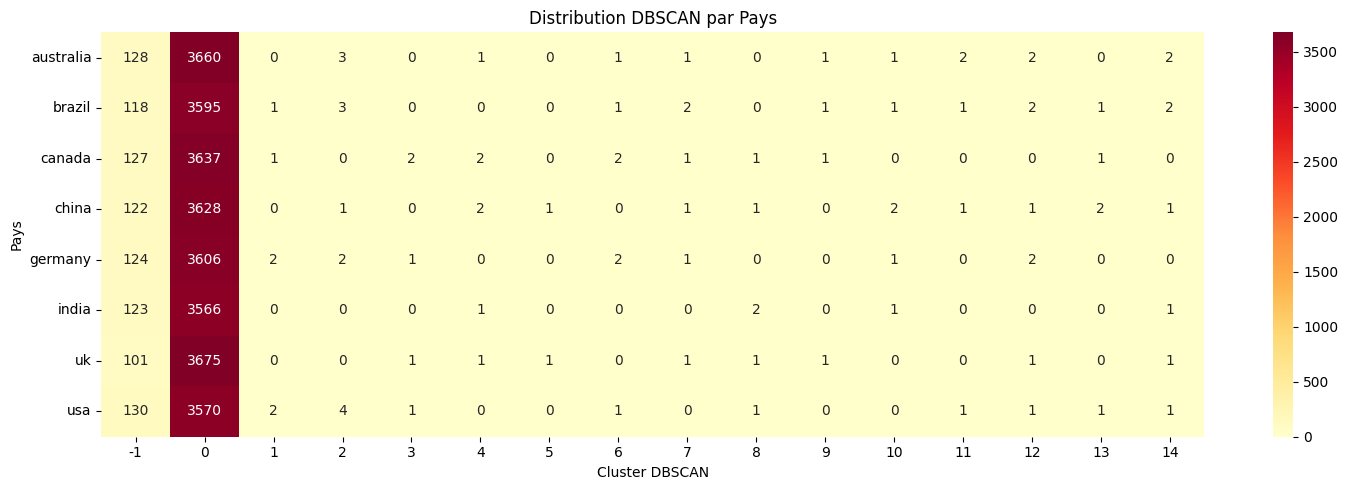

In [27]:

plt.figure(figsize=(15, 5))

if n_clusters > 0:
    cluster_by_country = df_engineered.groupby(['Location', 'DBSCAN_Cluster']).size().unstack(fill_value=0)
    sns.heatmap(cluster_by_country, annot=True, fmt='d', cmap='YlOrRd')
    plt.title('Distribution DBSCAN par Pays')
    plt.xlabel('Cluster DBSCAN')
    plt.ylabel('Pays')
else:
    plt.text(0.5, 0.5, 'Aucun cluster détecté', 
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('Aucun Cluster DBSCAN')

plt.tight_layout()
plt.show()


In [28]:

#  ANALYSE DÉTAILLÉE DES CLUSTERS

print(f"\nANALYSE DÉTAILLÉE DES CLUSTERS DBSCAN:")

for cluster_id in sorted(unique_labels):
    cluster_data = df_engineered[df_engineered['DBSCAN_Cluster'] == cluster_id]
    
    if cluster_id == -1:
        print(f"\n CLUSTER -1 (BRUIT - {len(cluster_data)} métiers):")
    else:
        print(f"\n CLUSTER {cluster_id} ({len(cluster_data)} métiers):")
    
    if len(cluster_data) > 0:
        # Statistiques de base
        growth = cluster_data['Job_Growth_Rate_%'].mean()
        salary = cluster_data['Median_Salary_USD'].mean()
        risk = cluster_data['Automation_Risk_%'].mean()
        remote = cluster_data['Remote_Work_Ratio_%'].mean()
        
        print(f"   Croissance: {growth:.1f}%")
        print(f"   Salaire: {salary:.0f} USD")
        print(f"     Risque automation: {risk:.1f}%")
        print(f"    Télétravail: {remote:.1f}%")
        
        # Top métiers
        top_jobs = cluster_data['Job_Title'].value_counts().head(3).index.tolist()
        print(f"    Top métiers: {', '.join(top_jobs)}")
        
        if cluster_id != -1:
            # Top pays pour les clusters normaux
            top_countries = cluster_data['Location'].value_counts().head(2).index.tolist()
            print(f"    Top pays: {', '.join(top_countries)}")


ANALYSE DÉTAILLÉE DES CLUSTERS DBSCAN:

 CLUSTER -1 (BRUIT - 973 métiers):
   Croissance: 2551.9%
   Salaire: 90341 USD
     Risque automation: 49.8%
    Télétravail: 50.7%
    Top métiers: civil service fast streamer, librarian, public, clinical molecular geneticist

 CLUSTER 0 (28937 métiers):
   Croissance: 56.5%
   Salaire: 90101 USD
     Risque automation: 50.2%
    Télétravail: 49.8%
    Top métiers: surveyor, insurance, counselling psychologist, surveyor, land/geomatics
    Top pays: uk, australia

 CLUSTER 1 (6 métiers):
   Croissance: 1709.7%
   Salaire: 128817 USD
     Risque automation: 64.8%
    Télétravail: 45.9%
    Top métiers: doctor, hospital, radiographer, diagnostic, fish farm manager
    Top pays: usa, germany

 CLUSTER 2 (13 métiers):
   Croissance: 1206.4%
   Salaire: 61780 USD
     Risque automation: 52.1%
    Télétravail: 37.8%
    Top métiers: surveyor, hydrographic, geneticist, molecular, teacher, primary school
    Top pays: usa, brazil

 CLUSTER 3 (5 métier

# **CAH** 

In [29]:
# **CAH (Clustering Ascendant Hiérarchique)**
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
# **CLUSTERING ASCENDANT HIÉRARCHIQUE (CAH) - CORRIGÉ**
print("CLUSTERING ASCENDANT HIÉRARCHIQUE (CAH)")


from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Vérification des colonnes requises
required = ['Location', 'Job_Title', 'Job_Growth_Rate_%']
missing = [c for c in required if c not in df_engineered.columns]
if missing:
    print(f"❌ Colonnes manquantes: {missing}")
else:
    # Création de la matrice pivot
    pivot_df = df_engineered.pivot_table(
        values='Job_Growth_Rate_%',
        index='Location',
        columns='Job_Title',
        aggfunc='mean'
    ).fillna(0)

    print(f"Pivot matrix shape (locations x jobs): {pivot_df.shape}")
    
    # Standardisation
    scaler = StandardScaler()
    pivot_scaled = scaler.fit_transform(pivot_df.values)   
    print(f"Scaled data mean: {pivot_scaled.mean():.3f}, std: {pivot_scaled.std():.3f}")
    print(f"Pays analysés : {pivot_df.index.tolist()}")


CLUSTERING ASCENDANT HIÉRARCHIQUE (CAH)
Pivot matrix shape (locations x jobs): (8, 639)
Scaled data mean: -0.000, std: 1.000
Pays analysés : ['australia', 'brazil', 'canada', 'china', 'germany', 'india', 'uk', 'usa']


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


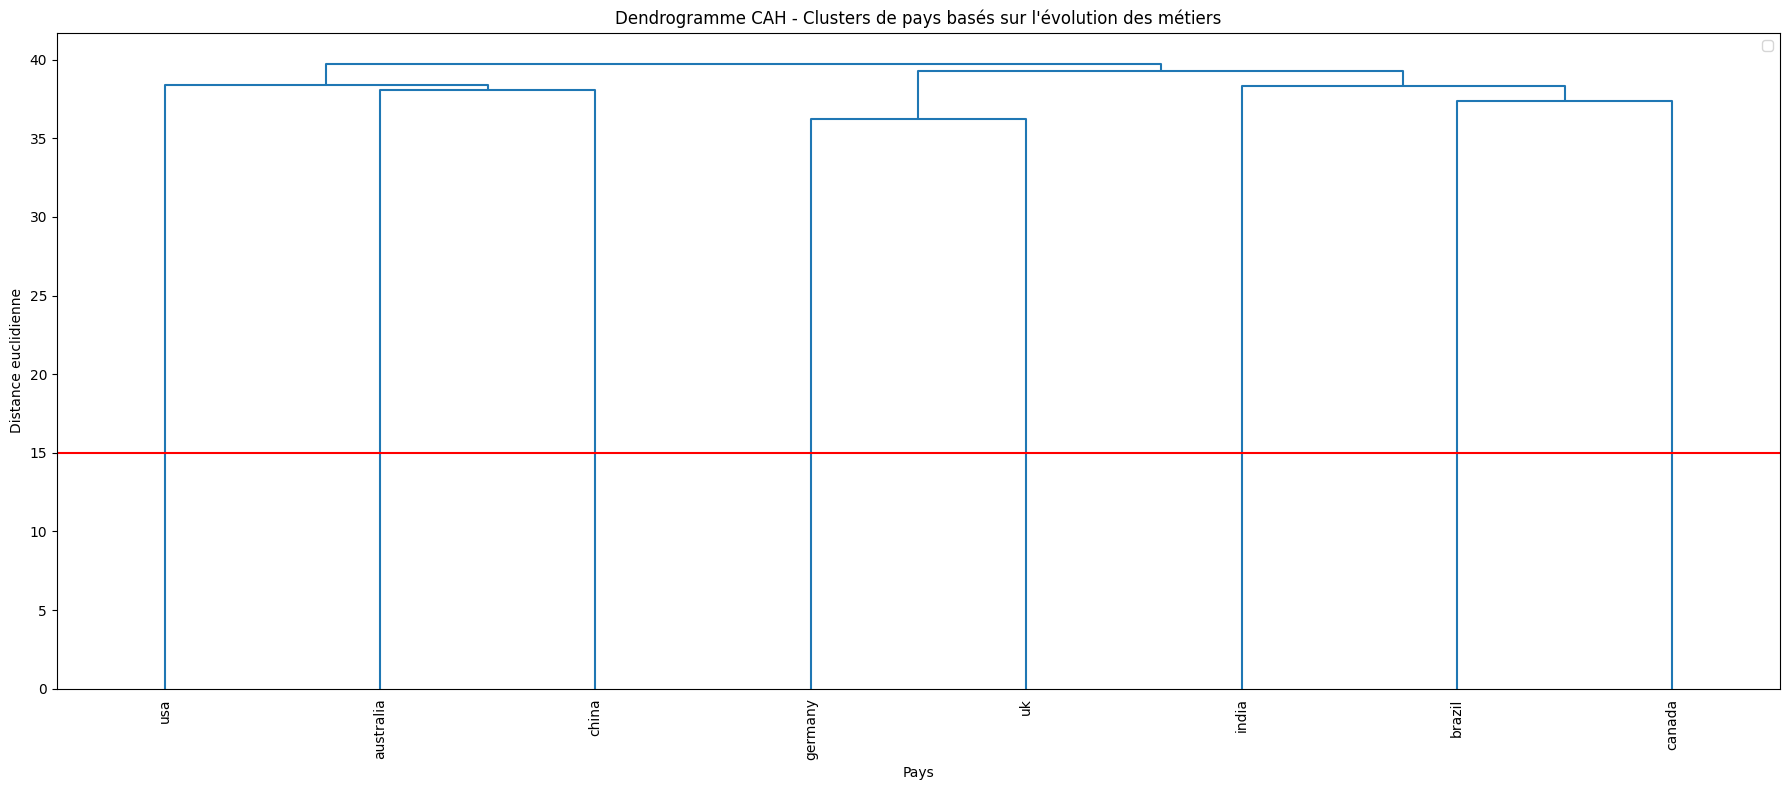

In [30]:
# Méthode 1: CAH avec scipy (pour le dendrogramme)
Z = linkage(pivot_scaled, method='ward', metric='euclidean')

# Visualisation du dendrogramme pour choisir le nombre de clusters
plt.figure(figsize=(18, 8))
dendrogram(Z,
          labels=pivot_df.index.tolist(),
          leaf_rotation=90,
          leaf_font_size=10,
          color_threshold=15)
plt.title('Dendrogramme CAH - Clusters de pays basés sur l\'évolution des métiers')
plt.axhline(y=15, color='r',)
plt.ylabel('Distance euclidienne')
plt.xlabel('Pays')
plt.legend()
plt.tight_layout()
plt.show()

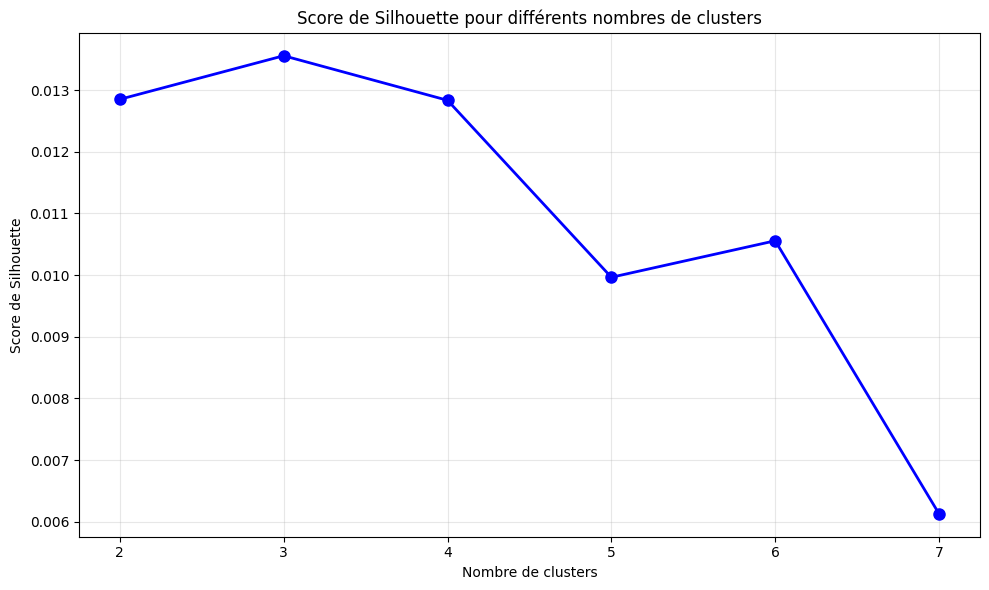

In [31]:
# Calcul du score de silhouette pour différents nombres de clusters
silhouette_scores = []
cluster_range = range(2, min(8, len(pivot_df)))  # Éviter plus de clusters que de pays

for n_clusters in cluster_range:
    # Méthode 2: CAH avec scikit-learn (plus moderne)
    hc = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='euclidean',
        linkage='ward'
    )
    cluster_labels = hc.fit_predict(pivot_scaled)

    if len(set(cluster_labels)) > 1:  # Éviter erreur si un seul cluster
        score = silhouette_score(pivot_scaled, cluster_labels)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(0)

# Visualisation des scores de silhouette
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.title('Score de Silhouette pour différents nombres de clusters')
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de Silhouette')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [32]:
# Choix du nombre optimal de clusters
optimal_clusters = cluster_range[np.argmax(silhouette_scores)]
print(f"Nombre optimal de clusters (selon silhouette) : {optimal_clusters}")

# Utilisation du nombre optimal ou d'une valeur fixe selon le contexte
num_clusters = optimal_clusters  


Nombre optimal de clusters (selon silhouette) : 3


In [33]:
hc_final = AgglomerativeClustering(
    n_clusters=num_clusters,
    metric='euclidean',
    linkage='ward'
)
clusters = hc_final.fit_predict(pivot_scaled)
pivot_df['Cluster'] = clusters

for cluster_num in range(num_clusters):
    countries_in_cluster = pivot_df[pivot_df['Cluster'] == cluster_num].index.tolist()
    print(f"Cluster {cluster_num}: {countries_in_cluster}")

def analyze_cluster_variations(cluster_matrix, cluster_num):
    cluster_means = cluster_matrix.mean(axis=0).sort_values(ascending=False)
    top_increase = cluster_means.head(10)
    top_decrease = cluster_means.tail(10)
    print(f"\nCluster {cluster_num} summary ")
    print(f"Countries: {', '.join(cluster_matrix.index.tolist())}")
    print(f"Mean growth (all jobs): {cluster_means.mean():+.2f}%")
    print("\nTop increases (jobs):")
    print(top_increase.head(5))
    print("\nTop decreases (jobs):")
    print(top_decrease.head(5))
    return top_increase, top_decrease
print("\nDETAILED CLUSTER VARIATIONS")
for c in range(num_clusters):
    cluster_data = pivot_df[pivot_df['Cluster'] == c].drop(columns='Cluster')
    analyze_cluster_variations(cluster_data, c)

Cluster 0: ['australia', 'china', 'usa']
Cluster 1: ['brazil', 'canada', 'india']
Cluster 2: ['germany', 'uk']

DETAILED CLUSTER VARIATIONS

Cluster 0 summary 
Countries: australia, china, usa
Mean growth (all jobs): +145.35%

Top increases (jobs):
Job_Title
corporate investment banker            930.615043
fast food restaurant manager           836.918759
midwife                                833.174353
scientist, research (life sciences)    830.338993
radiographer, therapeutic              825.239502
dtype: float64

Top decreases (jobs):
Job_Title
planning and development surveyor   -14.845926
acupuncturist                       -17.722892
engineer, water                     -18.670559
conference centre manager           -18.860748
textile designer                    -22.730027
dtype: float64

Cluster 1 summary 
Countries: brazil, canada, india
Mean growth (all jobs): +142.86%

Top increases (jobs):
Job_Title
jewellery designer                     1289.223569
ship broker            

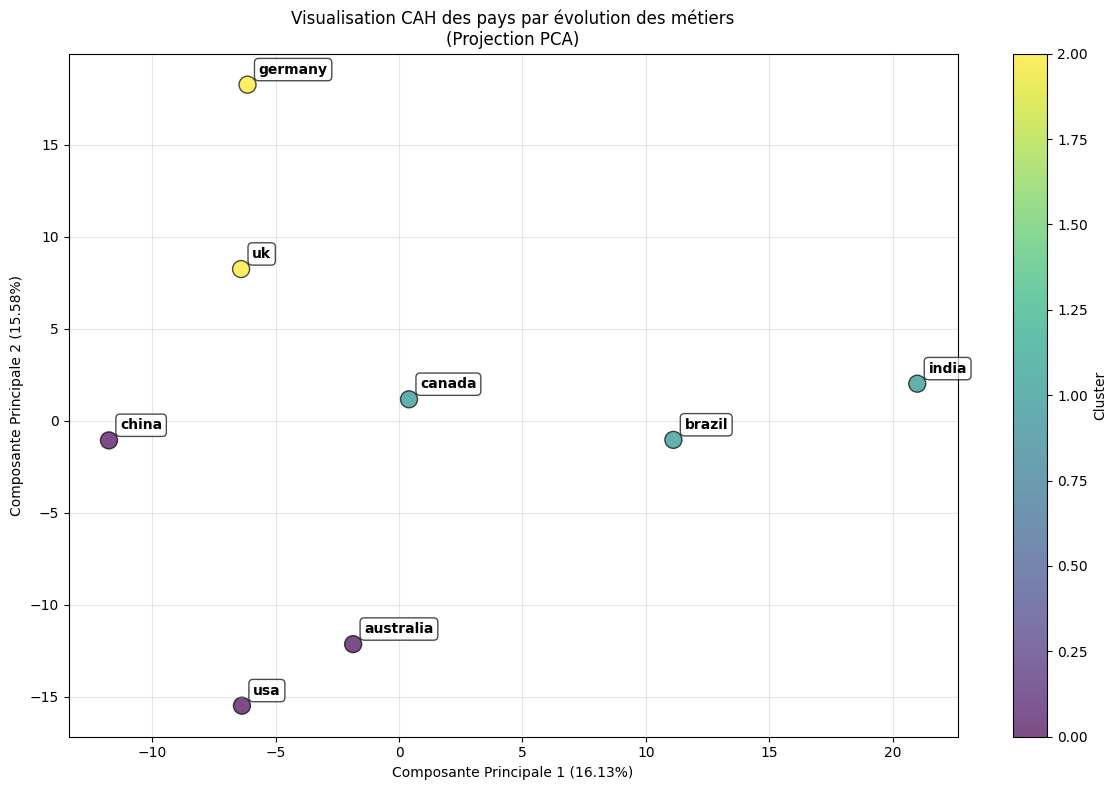

In [34]:
from sklearn.decomposition import PCA
# Réduction de dimension avec PCA
pca = PCA(n_components=2)
pivot_pca = pca.fit_transform(pivot_scaled)

# Créer un DataFrame pour la visualisation
pca_df = pd.DataFrame({
    'PC1': pivot_pca[:, 0],
    'PC2': pivot_pca[:, 1],
    'Cluster': clusters,
    'Country': pivot_df.index
})

plt.figure(figsize=(12, 8))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'],
                     cmap='viridis', s=150, alpha=0.7, edgecolors='black')
# Ajouter les labels des pays
for i, country in enumerate(pca_df['Country']):
    plt.annotate(country, (pca_df['PC1'][i], pca_df['PC2'][i]),
                xytext=(8, 8), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

plt.colorbar(scatter, label='Cluster')
plt.title('Visualisation CAH des pays par évolution des métiers\n(Projection PCA)')
plt.xlabel(f'Composante Principale 1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Composante Principale 2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Calcul des statistiques globales
cluster_stats = []
for cluster_num in range(num_clusters):
    cluster_data = pivot_df[pivot_df['Cluster'] == cluster_num].drop('Cluster', axis=1)
    countries = cluster_data.index.tolist()
    mean_growth = cluster_data.values.mean()
    std_growth = cluster_data.values.std()

    cluster_stats.append({
        'Cluster': cluster_num,
        'Pays': countries,
        'Croissance Moyenne': mean_growth,
        'Variabilité': std_growth
    })

# Tri par croissance moyenne
cluster_stats_sorted = sorted(cluster_stats, key=lambda x: x['Croissance Moyenne'], reverse=True)

for i, stats in enumerate(cluster_stats_sorted, 1):
    print(f"\n{i}. Cluster {stats['Cluster']}:")
    print(f"   Pays: {', '.join(stats['Pays'])}")
    print(f"   Croissance moyenne: {stats['Croissance Moyenne']:+.1f}%")
    print(f"   Variabilité: {stats['Variabilité']:.1f}%")

# Identification des tendances globales
most_growth_cluster = cluster_stats_sorted[0]
least_growth_cluster = cluster_stats_sorted[-1]

print(f"\n CONCLUSIONS STRATÉGIQUES:")
print(f"• Le cluster le plus dynamique est le Cluster {most_growth_cluster['Cluster']} "
      f"({most_growth_cluster['Croissance Moyenne']:+.1f}%)")
print(f"• Le cluster le plus en difficulté est le Cluster {least_growth_cluster['Cluster']} "
      f"({least_growth_cluster['Croissance Moyenne']:+.1f}%)")
print(f"• Score de silhouette moyen: {silhouette_score(pivot_scaled, clusters):.3f}")

print(f"\nANALYSE TERMINÉE AVEC SUCCÈS!")
print(f"• {len(pivot_df)} pays analysés")
print(f"• {pivot_df.shape[1]-1} métiers considérés")
print(f"• {num_clusters} clusters identifiés")



1. Cluster 0:
   Pays: australia, china, usa
   Croissance moyenne: +145.3%
   Variabilité: 253.9%

2. Cluster 1:
   Pays: brazil, canada, india
   Croissance moyenne: +142.9%
   Variabilité: 248.9%

3. Cluster 2:
   Pays: germany, uk
   Croissance moyenne: +124.4%
   Variabilité: 213.4%

 CONCLUSIONS STRATÉGIQUES:
• Le cluster le plus dynamique est le Cluster 0 (+145.3%)
• Le cluster le plus en difficulté est le Cluster 2 (+124.4%)
• Score de silhouette moyen: 0.014

ANALYSE TERMINÉE AVEC SUCCÈS!
• 8 pays analysés
• 639 métiers considérés
• 3 clusters identifiés
